In [48]:

%reset -f

import glob

import easygui
import numpy as np
from VicPy import VicDataSet
from geomfitty import fit3d, geom3d
from matplotlib import pyplot as plt


In [49]:
# Declare constants

plt.rcParams["font.family"] = "serif"

#DATA_DIR = easygui.diropenbox("Select Folder with out-Files")

YAW_ANGLE_FLAG = False
if YAW_ANGLE_FLAG:
    yaw_angle_file = easygui.fileopenbox("Select the Yaw Angle Time-Series File")
else:
    pass


In [50]:
# out_file_list = glob(DATA_DIR + "/*.out")
# frame_n = 8500#len(out_file_list)
#
# if YAW_ANGLE_FLAG:
#     yaw_angle_array = np.array(loadmat(yaw_angle_file)["yaw_wea"])[:frame_n].flatten()
#
#     yaw_angle_mean = np.mean(yaw_angle_array)
#     yaw_angle_med = np.median(yaw_angle_array)
#
#     fig1, ax1 = plt.subplots()
#     ax1.plot(yaw_angle_array)
#     ax1.set_xlim(0)
#     #ax1.set_ylim(0)
#     ax1.set_xlabel("Frame")
#     ax1.set_ylabel("Yaw Angle [°]")
#     ax1.grid()
#
#     z_rot_angle_array = yaw_angle_array - yaw_angle_med
#
#     z_rot_matrix_list = []
#     for z_rot_angle in z_rot_angle_array:
#         rot_z = np.array([[np.cos(z_rot_angle), -np.sin(z_rot_angle), 0],
#                           [np.sin(z_rot_angle), np.cos(z_rot_angle), 0],
#                           [0, 0, 1]])
#         z_rot_matrix_list.append(rot_z)
#
# else:
#     pass

In [51]:
def read_file(file_name, subset_index, check_aoi_is_empty=False):
    """
    Liest eine out-Datei ein und speichert eine Teilmenge der Punkte ab.

        file_name - Pfad zu der Out-Datei
        subset_index - Gibt an, welche Subsets zurueckgegeben werden sollen
    """

    data = VicDataSet()  # Creates an instance of a VicDataSet() class

    if not data.load(
            file_name
    ):  # Tries to load a .out file into the VicDataSet() instance, it exits if it fails
        print("Could not load data set\n\n")
        exit(-1)

    size = 0
    for aoi in range(
            data.numData()
    ):  # The numData() method returns the number of areas of interest in the dataset
        d = data.data(
            aoi
        )  # Returns a pointer to VicData objet for the specific AOI in the dataset
        size += d.matrixSize()

    found_array = np.empty(
        (size), int
    )  # gibt an, ob ein Subset gefunden wurde. 1 wenn gefunden, sonst 0
    coordinates = np.empty((size, 3), float)  # enthaelt die Koordinaten der Subsets
    xyz_sigmas = np.empty((size, 3), float)  # enthaelt die Sigma-Werte eines Subsets
    aoi_number = np.empty((size), int)  # gibt an in welcher AOI ein Subset liegt
    index_in_aoi = np.empty((size), int)  # Index des Subsets innerhalb der AOI

    index = 0
    for aoi in range(data.numData()):
        d = data.data(aoi)
        rows = d.asArray(
            ["sigma", "X", "Y", "Z", "U", "V", "W", "SIGMA_X", "SIGMA_Y", "SIGMA_Z"]
        )  # TODO: This array is the same as the hardcoded one on top?
        rows = rows.view(np.float32).reshape(rows.shape[0], -1)

        rows = rows.T  # TODO: I'm pretty sure this transpose is not needed
        found_array_for_aoi = np.where(rows[0] < 0, 0, 1)

        coordinates_for_aoi = (rows[1:4] + rows[4:7]).T
        xyz_sigma_for_aoi = rows[7:10].T

        if check_aoi_is_empty:
            assert len(np.where(found_array_for_aoi == 1)[0]) > 0, (
                f"No visible points were found in AoI {aoi}."
            )

        found_array[index: index + len(found_array_for_aoi)] = found_array_for_aoi
        coordinates[index: index + len(coordinates_for_aoi)] = coordinates_for_aoi
        xyz_sigmas[index: index + len(xyz_sigma_for_aoi)] = xyz_sigma_for_aoi
        aoi_number[index: index + len(xyz_sigma_for_aoi)] = np.full(
            (len(xyz_sigma_for_aoi)), aoi
        )
        index_in_aoi[index: index + len(xyz_sigma_for_aoi)] = np.arange(
            len(found_array_for_aoi)
        )

        index += len(found_array_for_aoi)

    if subset_index is not None:
        found_array = found_array[subset_index]
        coordinates = coordinates[subset_index]
        xyz_sigmas = xyz_sigmas[subset_index]
        aoi_number = aoi_number[subset_index]
        index_in_aoi = index_in_aoi[subset_index]

    return found_array, coordinates, xyz_sigmas, aoi_number, index_in_aoi

In [52]:
# # fig1 = plt.figure()
# # ax1 = fig1.add_subplot(projection="3d")
# #
# # fig2 = plt.figure()
# # ax2 = fig2.add_subplot()
# #
# # circle_dir_list = [] #[np.array([0.05502, -0.39940, -0.91513])]
# # circle_center_list = [] #[np.array([13960.16956, 28868.63545, -289172.31680])]
# # needed_angle_list = []
# # rot_axis_list = []
# #
# # for out_file in out_file_list:
#     # found_array, coordinates, xyz_sigmas, aoi_number, index_in_aoi = read_file(out_file)
#     #
#     # aoi_mean_coord = []
#     # for aoi in np.unique(aoi_number):
#     #     bool_mask = (aoi_number == aoi) & (found_array > 0)
#     #     aoi_mean_coord.append(np.mean(coordinates[bool_mask, :][::100], axis=0))
#     #
#     # aoi_mean_coord = np.array(aoi_mean_coord)
#     # center_point = np.mean(aoi_mean_coord, axis=0)
#     #
#     # dist_array = np.linalg.norm(aoi_mean_coord - center_point, axis=1)
#     # arg_dist = np.argsort(dist_array)
#     #
#     # dist_array = dist_array[arg_dist]
#     #
#     # for i in range(5):
#     #     bool_mask = ((aoi_number == arg_dist[3*i]) | (aoi_number == arg_dist[3*i+1]) | (aoi_number == arg_dist[3*i+2])) & (found_array > 0)
#     #     ax1.plot(coordinates[bool_mask
#     #     , 0][::100], coordinates[bool_mask, 1][::100], coordinates[bool_mask, 2][::100], linestyle='', marker='o', alpha=1)
#     #
#     #
#     # inner_rad = np.mean(dist_array[:3])/1000
#     # initial_guess = geom3d.Circle3D(center_point, [1, 0, 0], inner_rad)
#     # circle = fit3d.circle3D_fit(coordinates[((aoi_number == arg_dist[0]) | (aoi_number == arg_dist[1]) | (aoi_number == arg_dist[2])) & (found_array > 0)], initial_guess=initial_guess)
#     #
#     # circle_center_list.append(circle.center)
#     # circle_dir_list.append(circle.direction)
#     # #
#     # # needed_angle = np.rad2deg(np.arccos(np.dot(circle.direction, circle_dir_list[0])/(np.linalg.norm(circle_dir_list[0])*np.linalg.norm(circle.direction))))
#     #
#     # # if needed_angle > 90:
#     # #     needed_angle = needed_angle - 180
#     # # else:
#     # #     pass
# #
# #     needed_angle_list.append(needed_angle)
# #
# #     rot_axis = np.cross(circle.direction, circle_dir_list[0]) / np.linalg.norm(np.cross(circle.direction, circle_dir_list[0]))
# #     rot_axis_list.append(rot_axis)
# #
# # #
# circle_center_array = np.array(circle_center_list)
# circle_dir_array = np.array(circle_dir_list)
# circle_dir_array[-1] = -1*circle_dir_array[-1]
# # #
# color_list = ["blue", "orange", "pink"]
# legend_list = ["Average", "Frame 0", "Frame 3400"]
# for i in range(len(circle_center_array)):
#
#     random = np.array([1, 0, 0])
#     u = np.cross(circle_dir_array[i], random)
#     v = np.cross(circle_dir_array[i], u)
#     theta = np.linspace(0, 2 * np.pi, 100)
#
#     circle_pts = 41905 * (np.outer(u, np.cos(theta)) + np.outer(v, np.sin(theta)))
#     circle_pts = circle_center_array[i] + circle_pts.T
#
#     ax1.plot(circle_center_array[i][0], circle_center_array[i][1], circle_center_array[i][2], marker='D', color='black')
#
#     ax1.plot(circle_pts[:, 0],circle_pts[:, 1],circle_pts[:, 2], color_list[i])
#
#     ax1.quiver(circle_center_array[i][0], circle_center_array[i][1], circle_center_array[i][2], circle_dir_array[i][0]*10000, circle_dir_array[i][1]*10000, circle_dir_array[i][2]*10000, color=color_list[i], label=legend_list[i])
# #
# #
# #
#     ax2.plot(circle_pts[:, 1], circle_pts[:, 2], color=color_list[i])
# #
# #
# #     print(circle_dir_array[i])
# #
# ax1.quiver(np.mean(circle_center_array, axis=0)[0], np.mean(circle_center_array, axis=0)[1], np.mean(circle_center_array, axis=0)[2], 0.0371*10000, 0.9168*10000, -0.3979*10000, color="red")
#
# # ax2.quiver(np.mean(circle_center_array, axis=0)[1], np.mean(circle_center_array, axis=0)[2], 0.9168*10000, -0.3979*10000, color="red")
#
# ax1.legend()
# ax1.set_xlabel("x")
# ax1.set_ylabel("y")
# ax1.set_zlabel("z")


In [53]:
def calculate_circle_rotation_matrix(circle_direction, direction):


    """
    Compute the rotation matrix needed to rotate the vector normal to the circle surface to a specified direction
    """

# Ab hier Rechnung aus der Dissertation um Rotationsmatrix zu bestimmen
    circle_direction = np.array(circle_direction)
    k = (
            (direction * circle_direction) / (np.linalg.norm(circle_direction))
    )  # Manchmal zeigt der Rotor in die falsche Richtung. Dann muss das Vorzeichen von k angepasst werden
    n = np.array([1, 0, 0])

    v = np.cross(k, n)
    s = np.linalg.norm(v)
    c = np.dot(k, n)

    vx = np.array([[0, -v[2], v[1]], [v[2], 0, -v[0]], [-v[1], v[0], 0]])

    # finale Rotationsmatrix, die num immer zum Ausrichten des Koordinatensystems verwendet wird
    rotation_matrix = np.identity(3) + vx + np.dot(vx, vx) * ((1 - c) / s ** 2)

    ## Ende Rechnung
    return rotation_matrix

In [54]:
    # TODO. TEST


DATA_DIR = easygui.diropenbox("Select Folder with out-Files")
out_file_list = glob.glob(DATA_DIR + "/*.out")

test_subsets_list = np.loadtxt("test_subsets_list.csv", int)
indices_of_inner_subsets = np.loadtxt("indices_of_inner_subsets.csv", int)

better_rot_mat_list = []
better_circle_list = []
for idx, out_file in enumerate(out_file_list):
    found_array_b, coordinates_b, _, _, _ = read_file(
        out_file, test_subsets_list
    )

    better_center = np.mean(coordinates_b[indices_of_inner_subsets])

    better_rad = np.mean(
        np.linalg.norm(
            better_center
            - coordinates_b[indices_of_inner_subsets],
            axis=1,
        )
        / 1000
    )

    initial_guess = geom3d.Circle3D(
        np.mean(coordinates_b[indices_of_inner_subsets], axis=0),
        [1, 0, 0],
        better_rad,
    )
    better_circle = fit3d.circle3D_fit(
        coordinates_b[indices_of_inner_subsets],
        initial_guess=initial_guess,
    )

    better_circle_list.append(better_circle)


    rotation_matrix_better = calculate_circle_rotation_matrix(better_circle.direction, 1)

    better_rot_mat_list.append(rotation_matrix_better)


E:\HiWi Cordova\Messung 19_noyaw\plots\raw\messung19_000522_0.out
E:\HiWi Cordova\Messung 19_noyaw\plots\raw\messung19_003500_0.out


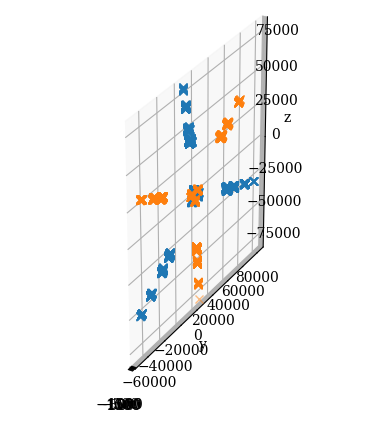

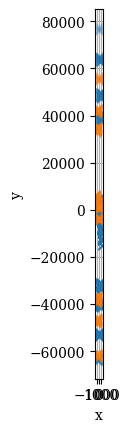

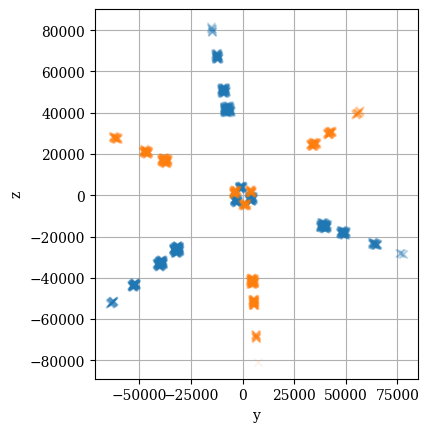

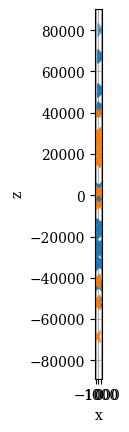

In [56]:
#out_file_list = glob(DATA_DIR + "/*.out")


fig1 = plt.figure()
ax1 = fig1.add_subplot(projection="3d")

fig2 = plt.figure()
ax2 = fig2.add_subplot()

fig3 = plt.figure()
ax3 = fig3.add_subplot()

fig4 = plt.figure()
ax4 = fig4.add_subplot()

rot_mat_ave = np.array([[0.05501613, -0.39939661, -0.91512599], [0.39939661, 0.84880075, -0.34643851],
                        [0.91512599, -0.34643851, 0.20621538]])

rot_mat_f0 = np.array([[0.13197481, -0.40132585, -0.90637752], [0.40132585, 0.85771553, -0.32134348],
                       [0.90637752, -0.32134348, 0.27425928]])

# angle_array = np.deg2rad(np.array([0, -(174.06672503906248 - 186.82105)]))
x_rot_angle = np.deg2rad(0)
rot_mat_x = np.array(
    [
        [1, 0, 0],
        [0, np.cos(x_rot_angle), -np.sin(x_rot_angle)],
        [0, np.sin(x_rot_angle), np.cos(x_rot_angle)],
    ]
)

for idx, out_file in enumerate(out_file_list):
    print(out_file)
    found_array, coordinates, xyz_sigmas, aoi_number, index_in_aoi = read_file(out_file, None)

    # rot_mat_z = np.array([
    #     [np.cos(angle_array[idx]), -np.sin(angle_array[idx]), 0],
    #     [np.sin(angle_array[idx]),  np.cos(angle_array[idx]), 0],
    #     [0, 0, 1]
    # ])

    aoi_mean_coord = []
    for aoi in np.unique(aoi_number):
        bool_mask = np.nonzero((aoi_number == aoi) & (found_array == 1))[0]
        #bool_mask = (aoi_number == aoi) & (found_array > 0)
        aoi_mean_coord.append(np.mean(coordinates[bool_mask, :][::100], axis=0))

    aoi_mean_coord = np.array(aoi_mean_coord)
    center_point = np.nanmean(aoi_mean_coord, axis=0)

    dist_array = np.linalg.norm(aoi_mean_coord - center_point, axis=1)
    arg_dist = np.argsort(dist_array)

    center_point = np.mean(aoi_mean_coord[arg_dist[:3]], axis=0)

    dist_array = dist_array[arg_dist]

    coordinates = coordinates - better_circle_list[idx].center

    coordinates = np.matmul(better_rot_mat_list[idx], coordinates.T).T
    coordinates = np.matmul(rot_mat_x, coordinates.T).T

    ax1.plot(coordinates[found_array > 0, 0][::10], coordinates[found_array > 0, 1][::10],
             coordinates[found_array > 0, 2][::10], linestyle='', marker='x', alpha=0.5)
    ax1.set_xlabel("x")
    ax1.set_ylabel("y")
    ax1.set_zlabel("z")
    ax1.set_aspect("equal")

    ax2.plot(coordinates[found_array > 0, 0][::10], coordinates[found_array > 0, 1][::10], linestyle='', marker='x',
             alpha=0.1)
    ax2.set_aspect("equal")
    ax2.set_xlabel("x")
    ax2.set_ylabel("y")
    ax2.grid(True)

    ax3.plot(coordinates[found_array > 0, 1][::10], coordinates[found_array > 0, 2][::10], linestyle='', marker='x',
             alpha=0.1)
    ax3.set_aspect("equal")
    ax3.set_xlabel("y")
    ax3.set_ylabel("z")
    ax3.grid(True)

    ax4.plot(coordinates[found_array > 0, 0][::10], coordinates[found_array > 0, 2][::10], linestyle='', marker='x',
             alpha=0.1)
    ax4.set_aspect("equal")
    ax4.set_xlabel("x")
    ax4.set_ylabel("z")
    ax4.grid(True)

    # ax2.plot(circle.center[1], circle.center[2], marker='D', color='black')
    # ax2.set_xlabel("y")
    # ax2.set_ylabel("z")

